# Agent

## Tokenizer

In [5]:
from transformers import PreTrainedTokenizerFast

chat_template = """
{%- set default_system = 'Hãy thực hiện theo yêu cầu' -%}
{%- set ns = namespace(system=default_system) -%}
{%- if messages[0]['role'] == 'system' -%}{%- set ns.system = messages[0]['content'] -%}{%- endif -%}
{{- '<|im_start|>system\n' -}}
{{- ns.system }}
{%- if tools %}
Bạn có thể dùng các công cụ sau:
<tools>
{%- for tool in tools %}
{{- '\n' + (tool | tojson) }}
{%- endfor %}
</tools>
Khi cần gọi công cụ, trả về:
<tool_call>
{"name": <tên-hàm>, "arguments": <tham-số>}
</tool_call>
{%- endif %}
{{- '<|im_end|>\n' }}
{%- for message in messages %}
{%- if loop.first and message['role'] == 'system' %}
{%- continue %}
{%- endif %}
{%- if message['role'] == 'tool' %}
{%- if loop.first or messages[loop.index0-1]['role'] != 'tool' %}
{{- '<|im_start|>user\n' }}
{%- endif %}
{{- '<tool_response>\n' + message['content'] + '\n</tool_response>' }}
{%- if loop.last or messages[loop.index0+1]['role'] != 'tool' %}
{{- '<|im_end|>\n' }}
{%- endif %}
{%- elif message['role'] == 'assistant' %}
{{- '<|im_start|>assistant' }}
{%- if message.get('content') %}{{- '\n' + message['content'] }}{% endif %}
{%- for tc in message.get('tool_calls', []) %}
{%- set f = tc.get('function', tc) %}
{{- '\n<tool_call>\n{"name": "' + f['name'] + '", "arguments": ' + (f['arguments'] | tojson) + '}\n</tool_call>' }}
{%- endfor %}
{{- '<|im_end|>\n' }}
{%- else %}
{{- '<|im_start|>' + message['role'] + '\n' + message['content'] + '<|im_end|>\n' }}
{%- endif %}
{%- endfor %}
{%- if add_generation_prompt %}{{- '<|im_start|>assistant\n' }}{% endif %}
""".strip()
# additional_special_tokens = ["<|im_start|>", "<|im_end|>"]

tokenizer = PreTrainedTokenizerFast(tokenizer_file="./SpikeGPT/20B_tokenizer.json", chat_template = chat_template)

c:\Users\pikke\miniconda3\envs\bt\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
tools = [
    {
        "name": "check_inventory",
        "description": "Kiểm tra tồn kho",
        "parameters": {
            "properties": {
                "product_id": "ID sản phẩm"
            },
        }
    },
    {
        "name": "revenue_analysis",
        "description": "Thống kê doanh thu",
        "parameters": {
            "properties": {
                "start_date": "Ngày bắt đầu (YYYY-MM-DD)",
                "end_date":  "Ngày kết thúc (YYYY-MM-DD)"
            }
        }
    },
    {
        "name": "get_order",
        "description": "Kiểm tra đơn hàng",
        "parameters": {
            "properties": {
                "order_id": "ID đơn hàng"
            }
        }
    },
    {
        "name": "create_order",
        "description": "Tạo đơn hàng mới",
        "parameters": {
            "type": "object",
            "properties": {
                "product_id": "ID sản phẩm",
                "quantity":  "Số lượng",
                "address": "Địa chỉ giao hàng"
            }
        }
    },
    {
        "name": "update_order",
        "description": "Cập nhật đơn hàng",
        "parameters": {
            "properties": {
                "order_id":  "ID đơn hàng",
                "quantity": "Số lượng mới",
                "address": "Địa chỉ mới"
            },
        }
    },
    {
        "name": "delete_order",
        "description": "Hủy đơn hàng",
        "parameters": {
            "properties": {
                "order_id":"ID đơn hàng"
            }
        }
    }
]

messages = [
  {
    "role": "user",
    "content": "Kho còn bao nhiêu sản phẩm có ID là P100?"
  },
  {
    "role": "assistant",
    "content": "",
    "tool_calls": [
      {
        "name": "check_inventory",
        "arguments": {
          "product_id": "P100"
        }
      }
    ]
  }
]

print(tokenizer.decode(tokenizer.apply_chat_template(messages, tokenize=True)))
print(len(tokenizer.encode(tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True))))

<|im_start|>system
Hãy thực hiện theo yêu cầu<|im_end|>
<|im_start|>user
Kho còn bao nhiêu sản phẩm có ID là P100?<|im_end|>
<|im_start|>assistant
<tool_call>
{"name": "check_inventory", "arguments": {"product_id": "P100"}}
</tool_call><|im_end|>

89


**Loading Data**

In [3]:
import json

with open('./data/agent_data1.json', 'r', encoding='utf-8') as f:
    data = json.load(f)

print(data)

[{'id': 'sample_001', 'description': 'Kiểm tra tồn kho của một sản phẩm', 'tool_used': ['check_inventory'], 'messages': [{'role': 'user', 'content': 'Bạn kiểm tra giúp tôi xem mã sản phẩm SP-8845 trong kho còn hàng không nhé.'}, {'role': 'assistant', 'content': None, 'tool_calls': [{'name': 'check_inventory', 'arguments': {'product_id': 'SP-8845'}}]}]}, {'id': 'sample_002', 'description': 'Tạo đơn hàng mới (Ví dụ gốc của bạn)', 'tool_used': ['create_order'], 'messages': [{'role': 'user', 'content': 'Tôi muốn đặt 3 sản phẩm P200 giao đến 123 Lê Lợi, TP.HCM.'}, {'role': 'assistant', 'content': None, 'tool_calls': [{'name': 'create_order', 'arguments': {'product_id': 'P200', 'quantity': 3, 'address': '123 Lê Lợi, TP.HCM'}}]}]}, {'id': 'sample_003', 'description': 'Thống kê doanh thu trong một khoảng thời gian', 'tool_used': ['revenue_analysis'], 'messages': [{'role': 'user', 'content': 'Cho tôi xem báo cáo thống kê doanh thu từ ngày 1 tháng 4 năm 2026 đến ngày 15 tháng 4 năm 2026.'}, {'ro

In [3]:
import pandas as pd

ds = pd.read_json("./data/agent_data1.json")
ds

,id,description,tool_used,messages
0,sample_001,Kiểm tra tồn kho của một sản phẩm,[check_inventory],"[{'role': 'user', 'content': 'Bạn kiểm tra giú..."
1,sample_002,Tạo đơn hàng mới (Ví dụ gốc của bạn),[create_order],"[{'role': 'user', 'content': 'Tôi muốn đặt 3 s..."
2,sample_003,Thống kê doanh thu trong một khoảng thời gian,[revenue_analysis],"[{'role': 'user', 'content': 'Cho tôi xem báo ..."
3,sample_004,Tra cứu thông tin đơn hàng hiện tại,[get_order],"[{'role': 'user', 'content': 'Đơn hàng ORD-112..."
4,sample_005,Cập nhật đơn hàng (thay đổi cả số lượng và địa...,[update_order],"[{'role': 'user', 'content': 'Tôi muốn cập nhậ..."
...,...,...,...,...
1905,2240,Cập nhật đơn hàng phụ kiện,[update_order],"[{'role': 'user', 'content': 'Sửa đơn hàng mã ..."
1906,2242,Hủy đơn hàng do lỡ tay,[delete_order],"[{'role': 'user', 'content': 'Hủy hộ cái đơn v..."
1907,2250,Hủy đơn hàng vì không cần nữa,[delete_order],"[{'role': 'user', 'content': 'Xóa đơn hàng ORD..."
1908,2256,Hủy đơn hàng cuối cùng trong ngày,[delete_order],"[{'role': 'user', 'content': 'Tôi muốn hủy yêu..."


**Check Data**

In [5]:
total = len(ds)
mistake = 0

for i, data in ds.iterrows():  # Unpack (index, row)
    tools_in_messages = []
    for msg in data["messages"]:
        if "tool_calls" in msg and msg["tool_calls"]:
            for tool_call in msg["tool_calls"]:
                try:
                    tools_in_messages.append(tool_call["name"])
                except:
                    print(f"Error in sample {i}")

    tool_used = data["tool_used"]

    is_match = set(tools_in_messages) == set(tool_used)
    if not is_match:
        print(f"Data {i} has error!")
        print("Tools in messages:", tools_in_messages) 
        print("Tool used:        ", tool_used)      
    
        mistake += 1

print("Total error data:", mistake)

Total error data: 0


## Preprocessing

In [1]:
import random
import copy
import re
import json
import pandas as pd
from typing import List, Tuple, Dict, Any
import calendar

# ---------------------------------------------------------------------------
# Helper
# ---------------------------------------------------------------------------

def _random_quantity(original: int, *, low: int = 1, high: int = 1000) -> int:
    """Return a random quantity that differs from the original."""
    candidate = random.randint(low, high)
    # Guarantee it's different from the original
    while candidate == original:
        candidate = random.randint(low, high)
    return candidate


def _random_date_pair(year: int = 2026, month: int = None) -> Tuple[str, str]:
    """
    Return a random (start_date, end_date) pair for a given year and month.
    If no month is provided, a random month is chosen.
    """
    if month is None:
        month = random.randint(1, 12)
        
    # calendar.monthrange returns (first_weekday, number_of_days)
    # This automatically handles leap years for February!
    _, max_days = calendar.monthrange(year, month)
    
    # Generate two random days within the month
    day1 = random.randint(1, max_days)
    day2 = random.randint(1, max_days)
    
    # Ensure the start date is always before or equal to the end date
    start_day = min(day1, day2)
    end_day = max(day1, day2)
    
    return f"{year}-{month:02d}-{start_day:02d}", f"{year}-{month:02d}-{end_day:02d}"


# ---------------------------------------------------------------------------
# Augmentation
# ---------------------------------------------------------------------------

def augment(
    sample: Dict[str, Any],
    addresses: List[str],
    n_variations: int = 5,
) -> List[Dict[str, Any]]:
    augmented_samples = []

    for i in range(n_variations):
        new_sample = copy.deepcopy(sample)
        new_sample["id"] = f"{sample['id']}_aug_{i}"
        messages = new_sample["messages"]

        # Find indices of specific roles
        user_msg_idx = next(
            (j for j, m in enumerate(messages) if m.get("role") == "user"), None
        )
        assistant_tool_idx = next(
            (j for j, m in enumerate(messages)
             if m.get("role") == "assistant" and m.get("tool_calls")), None
        )
        tool_result_idx = next(
            (j for j, m in enumerate(messages) if m.get("role") == "tool"), None
        )
        final_assistant_idx = next(
            (j for j, m in enumerate(messages)
             if m.get("role") == "assistant" and not m.get("tool_calls")), None
        )

        if user_msg_idx is None or assistant_tool_idx is None:
            break

        tool_calls = messages[assistant_tool_idx].get("tool_calls")
        if not tool_calls:
            break

        args: dict = tool_calls[0].get("arguments", {})
        user_msg: str = messages[user_msg_idx].get("content") or ""

        # Parse tool result content
        tool_result_data = {}
        if tool_result_idx is not None and messages[tool_result_idx].get("content"):
            try:
                tool_result_data = json.loads(messages[tool_result_idx]["content"])
            except (json.JSONDecodeError, TypeError):
                pass

        # Track replacements: (old_value, new_value)
        replacements: List[Tuple[str, str]] = []

        # 1. Order ID
        if args.get("order_id") is not None:
            old_oid = str(args["order_id"])
            if old_oid in user_msg:
                prefix = re.match(r"^[A-Za-z]+", old_oid)
                prefix_str = prefix.group() if prefix else ""
                new_oid = f"{prefix_str}{random.randint(1000, 9999)}"
                
                args["order_id"] = new_oid
                replacements.append((old_oid, new_oid))
                if isinstance(tool_result_data, dict) and "order_id" in tool_result_data:
                    tool_result_data["order_id"] = new_oid

        # 2. Quantity
        if args.get("quantity") is not None:
            old_qty = str(args["quantity"])
            if old_qty in user_msg:
                new_qty = str(_random_quantity(int(old_qty)))
                args["quantity"] = int(new_qty)
                replacements.append((old_qty, new_qty))

        # 3. Product ID
        if args.get("product_id") is not None:
            old_pid = str(args["product_id"])
            if old_pid in user_msg:
                prefix = re.match(r"^[A-Za-z]+", old_pid)
                prefix_str = prefix.group() if prefix else ""
                new_pid = f"{prefix_str}{random.randint(1000, 9999)}"
                
                args["product_id"] = new_pid
                replacements.append((old_pid, new_pid))
                if isinstance(tool_result_data, dict) and "product_id" in tool_result_data:
                    tool_result_data["product_id"] = new_pid

        # 4. Address
        if args.get("address") is not None and addresses:
            old_addr = str(args["address"])
            if old_addr in user_msg:
                choices = [a for a in addresses if a != old_addr] or addresses
                new_addr = random.choice(choices)
                
                args["address"] = new_addr
                replacements.append((old_addr, new_addr))
                if isinstance(tool_result_data, dict) and "address" in tool_result_data:
                    tool_result_data["address"] = new_addr

        # 5. Date range
        if args.get("start_date") is not None:
            old_start = str(args["start_date"])
            if old_start in user_msg:
                old_end = args.get("end_date") or ""
                new_start, new_end = _random_date_pair()
                
                args["start_date"] = new_start
                replacements.append((old_start, new_start))
                if args.get("end_date") and old_end:
                    args["end_date"] = new_end
                    replacements.append((str(old_end), new_end))

        # If no fields matched to be replaced, stop trying variations for this sample
        if not replacements:
            break

        # --- Safe replacement logic ---
        # FIX: Re-added Regex boundaries so quantities don't corrupt dates/addresses
        def apply_replacements(text: str) -> str:
            if not text:
                return text
            sorted_replacements = sorted(replacements, key=lambda x: len(str(x[0])), reverse=True)
            
            for old_val, new_val in sorted_replacements:
                old_str = str(old_val)
                new_str = str(new_val)
                
                if re.match(r'^[\w\-]+$', old_str):
                    pattern = rf"(?<![\w\-]){re.escape(old_str)}(?![\w\-])"
                    text = re.sub(pattern, new_str, text)
                else:
                    text = text.replace(old_str, new_str)
            return text

        # Apply replacements to user message
        messages[user_msg_idx]["content"] = apply_replacements(user_msg)

        # Update tool result
        if tool_result_idx is not None:
            if tool_result_data:
                messages[tool_result_idx]["content"] = json.dumps(
                    tool_result_data, ensure_ascii=False
                )
            else:
                messages[tool_result_idx]["content"] = apply_replacements(
                    messages[tool_result_idx].get("content", "")
                )

        # Update final assistant message
        if final_assistant_idx is not None and messages[final_assistant_idx].get("content"):
            messages[final_assistant_idx]["content"] = apply_replacements(
                messages[final_assistant_idx]["content"]
            )

        augmented_samples.append(new_sample)

    return augmented_samples

# ---------------------------------------------------------------------------
# Preprocessing
# ---------------------------------------------------------------------------

def preprocessing(
    ds: pd.DataFrame,
    tokenizer: Any,
    addresses: List[str],
    max_tokens: int = 700,
    n_variations: int = 10,
) -> pd.DataFrame:
    """
    Filter samples by token length, then augment each passing sample.
    """
    def token_count(messages: List[Dict[str, Any]]) -> int:
        token_ids = tokenizer.apply_chat_template(messages, tokenize=True)
        return len(token_ids)

    rows: List[Dict[str, Any]] = []

    # Using to_dict('records') is significantly faster than iterrows()
    for sample in ds.to_dict('records'):
        if token_count(sample["messages"]) <= max_tokens:
            rows.append(sample)
            samples = augment(sample, addresses=addresses, n_variations=n_variations)
            if samples:
                rows.extend(samples)

    return pd.DataFrame(rows)


In [6]:

addresses = [
    # TP. Hồ Chí Minh
    "12 Nguyễn Huệ, Phường Bến Nghé, Quận 1, TP. Hồ Chí Minh",
    "45 Lê Lợi, Phường Bến Thành, Quận 1, TP. Hồ Chí Minh",
    "78 Trần Hưng Đạo, Phường Cầu Kho, Quận 1, TP. Hồ Chí Minh",
    "23 Võ Văn Tần, Phường 6, Quận 3, TP. Hồ Chí Minh",
    "101 Đinh Tiên Hoàng, Phường 3, Quận Bình Thạnh, TP. Hồ Chí Minh",
    "56 Phan Văn Trị, Phường 10, Quận Gò Vấp, TP. Hồ Chí Minh",
    "88 Nguyễn Thị Thập, Phường Tân Phú, Quận 7, TP. Hồ Chí Minh",
    "34 Lê Văn Việt, Phường Hiệp Phú, Quận 9, TP. Hồ Chí Minh",
    "210 Quang Trung, Phường 10, Quận Gò Vấp, TP. Hồ Chí Minh",
    "67 Âu Cơ, Phường 14, Quận Tân Bình, TP. Hồ Chí Minh",

    # Hà Nội
    "15 Hàng Bài, Phường Hàng Bài, Quận Hoàn Kiếm, Hà Nội",
    "92 Nguyễn Chí Thanh, Phường Láng Thượng, Quận Đống Đa, Hà Nội",
    "38 Trần Duy Hưng, Phường Trung Hoà, Quận Cầu Giấy, Hà Nội",
    "5 Kim Mã, Phường Kim Mã, Quận Ba Đình, Hà Nội",
    "120 Lê Duẩn, Phường Khâm Thiên, Quận Đống Đa, Hà Nội",
    "77 Xuân Thủy, Phường Dịch Vọng Hậu, Quận Cầu Giấy, Hà Nội",
    "49 Hoàng Quốc Việt, Phường Nghĩa Đô, Quận Cầu Giấy, Hà Nội",

    # Đà Nẵng
    "22 Bạch Đằng, Phường Hải Châu 1, Quận Hải Châu, Đà Nẵng",
    "88 Nguyễn Văn Linh, Phường Nam Dương, Quận Hải Châu, Đà Nẵng",
    "14 Lê Duẩn, Phường Thạch Thang, Quận Hải Châu, Đà Nẵng",
    "66 Trần Phú, Phường Phước Ninh, Quận Hải Châu, Đà Nẵng",
    "31 Phan Chu Trinh, Phường Thạch Thang, Quận Hải Châu, Đà Nẵng",

    # Bình Dương
    "9 Đại lộ Bình Dương, Phường Hiệp Thành, TP. Thủ Dầu Một, Bình Dương",
    "203 Nguyễn Văn Tiết, Phường Lái Thiêu, TP. Thuận An, Bình Dương",
    "57 Trần Văn Ơn, Phường Phú Lợi, TP. Thủ Dầu Một, Bình Dương",

    # Đồng Nai
    "18 Phạm Văn Thuận, Phường Thống Nhất, TP. Biên Hòa, Đồng Nai",
    "74 Nguyễn Ái Quốc, Phường Quang Vinh, TP. Biên Hòa, Đồng Nai",
    "32 Đồng Khởi, Phường Tân Hiệp, TP. Biên Hòa, Đồng Nai",

    # Cần Thơ
    "10 Hòa Bình, Phường Tân An, Quận Ninh Kiều, Cần Thơ",
    "88 Trần Văn Hoài, Phường Xuân Khánh, Quận Ninh Kiều, Cần Thơ",
    "45 Nguyễn Trãi, Phường An Hội, Quận Ninh Kiều, Cần Thơ",

    # Hải Phòng
    "56 Điện Biên Phủ, Phường Minh Khai, Quận Hồng Bàng, Hải Phòng",
    "23 Lê Lợi, Phường Minh Khai, Quận Hồng Bàng, Hải Phòng",
    "11 Trần Phú, Phường Hoàng Diệu, Quận Dương Kinh, Hải Phòng",

    # Khánh Hòa
    "3 Trần Phú, Phường Lộc Thọ, TP. Nha Trang, Khánh Hòa",
    "99 Nguyễn Thiện Thuật, Phường Phương Sài, TP. Nha Trang, Khánh Hòa",
    "47 Yersin, Phường Phương Sài, TP. Nha Trang, Khánh Hòa",

    # Lâm Đồng
    "8 Trần Phú, Phường 3, TP. Đà Lạt, Lâm Đồng",
    "52 Bùi Thị Xuân, Phường 2, TP. Đà Lạt, Lâm Đồng",
    "19 Nguyễn Văn Trỗi, Phường 2, TP. Đà Lạt, Lâm Đồng",

    # Thừa Thiên Huế
    "20 Lê Lợi, Phường Vĩnh Ninh, TP. Huế, Thừa Thiên Huế",
    "7 Hùng Vương, Phường Phú Nhuận, TP. Huế, Thừa Thiên Huế",
    "36 Nguyễn Huệ, Phường Phú Nhuận, TP. Huế, Thừa Thiên Huế",

    # Nghệ An
    "14 Nguyễn Thị Minh Khai, Phường Lê Lợi, TP. Vinh, Nghệ An",
    "88 Trường Thi, Phường Trường Thi, TP. Vinh, Nghệ An",

    # Quảng Ninh
    "33 Lê Thánh Tông, Phường Bạch Đằng, TP. Hạ Long, Quảng Ninh",
    "71 Trần Quốc Nghiễn, Phường Hồng Gai, TP. Hạ Long, Quảng Ninh",

    # Bà Rịa - Vũng Tàu
    "25 Trần Hưng Đạo, Phường 1, TP. Vũng Tàu, Bà Rịa - Vũng Tàu",
    "60 Lê Hồng Phong, Phường 4, TP. Vũng Tàu, Bà Rịa - Vũng Tàu",

    # Long An
    "12 Hùng Vương, Phường 2, TP. Tân An, Long An",
]

new_data = preprocessing(ds, tokenizer, addresses=addresses)

[{'role': 'user',
  'content': 'Tạo đơn mua 551 đôi giày NIKE1165 gửi 32 Đồng Khởi, Phường Tân Hiệp, TP. Biên Hòa, Đồng Nai.'},
 {'role': 'assistant',
  'content': None,
  'tool_calls': [{'name': 'create_order',
    'arguments': {'product_id': 'NIKE1165',
     'quantity': 551,
     'address': '32 Đồng Khởi, Phường Tân Hiệp, TP. Biên Hòa, Đồng Nai'}}]}]

## Save in jsonl file

In [39]:
import json
from sklearn.model_selection import train_test_split

# ── 1. Split ────────────────────────────────────────────────────────────────
train_df, valid_df = train_test_split(
    new_data,
    test_size=0.2,    
    random_state=42,
    shuffle=True,
)

print(f"Train: {len(train_df)} | Valid: {len(valid_df)}")

# ── 2. Helper ────────────────────────────────────────────────────────────────
def save_jsonl(df, path: str, tokenizer) -> int:
    """
    Áp dụng chat template và lưu ra file JSONL.
    Trả về số lượng sample bị skip.
    """
    skipped = 0
    written = 0

    with open(path, "w", encoding="utf-8") as f:
        for _, example in df.iterrows():
            try:
                text = tokenizer.apply_chat_template(
                    example["messages"],
                    tokenize=False,
                    add_generation_prompt=False,
                )

                if not text or not text.strip():
                    skipped += 1
                    continue

                json.dump({"text": text}, f, ensure_ascii=False)
                f.write("\n")
                written += 1

            except Exception as e:
                print(f"[WARNING] Skipping example {example.get('id', '?')}: {e}")
                skipped += 1

    print(f"[INFO] Saved {written} examples to {path} | Skipped: {skipped}")
    return skipped

# ── 3. Save ──────────────────────────────────────────────────────────────────
total_skipped = 0
total_skipped += save_jsonl(train_df, "data/train_tool_data.jsonl", tokenizer)
total_skipped += save_jsonl(valid_df, "data/valid_tool_data.jsonl", tokenizer)

print(f"\n[DONE] Total skipped: {total_skipped}")

Train: 12648 | Valid: 3162
[INFO] Saved 12648 examples to data/train_tool_data.jsonl | Skipped: 0
[INFO] Saved 3162 examples to data/valid_tool_data.jsonl | Skipped: 0

[DONE] Total skipped: 0


# **Base**

## **Dataset**

### **VietGPT**

In [ ]:
from datasets import load_dataset
dataset = load_dataset("vietgpt/wikipedia_vi", split= "train")

**EDA**

In [ ]:
dataset

Dataset({
    features: ['id', 'revid', 'url', 'title', 'text'],
    num_rows: 1284930
})

In [12]:
dataset[1]

{'id': 4,
 'revid': '686003',
 'url': 'https://vi.wikipedia.org/wiki?curid=4',
 'title': 'Internet Society',
 'text': 'Internet Society hay ISOC là một tổ chức quốc tế hoạt động phi lợi nhuận, phi chính phủ và bao gồm các thành viên có trình độ chuyên ngành. Tổ chức này chú trọng đến: tiêu chuẩn, giáo dục và các vấn đề về chính sách. Với trên 145 tổ chức thành viên và 65.000 thành viên cá nhân, ISOC bao gồm những con người cụ thể trong cộng đồng Internet. Mọi chi tiết có thể tìm thấy tại website của ISOC.\nInternet Society nằm ở gần thủ đô Washington, DC, Hoa Kỳ và Geneva, Thụy Sĩ. Số hội viên của nó bao gồm hơn 145 tổ chức thành viên và hơn 65.000 cá nhân. Thành viên còn có thể tự lập một chi nhánh của tổ chức tùy theo vị trí hoặc sở thích. Hiện nay tổ chức có tới 90 chi nhánh trên toàn thế giới.\nNhiệm vụ và mục đích hoạt động.\nBảo đảm, cổ vũ cho sự phát triển, mở rộng và sử dụng Internet được thuận lợi nhất cho mọi người trên toàn thế giới.'}

In [ ]:
text_data = list(dataset['text'])

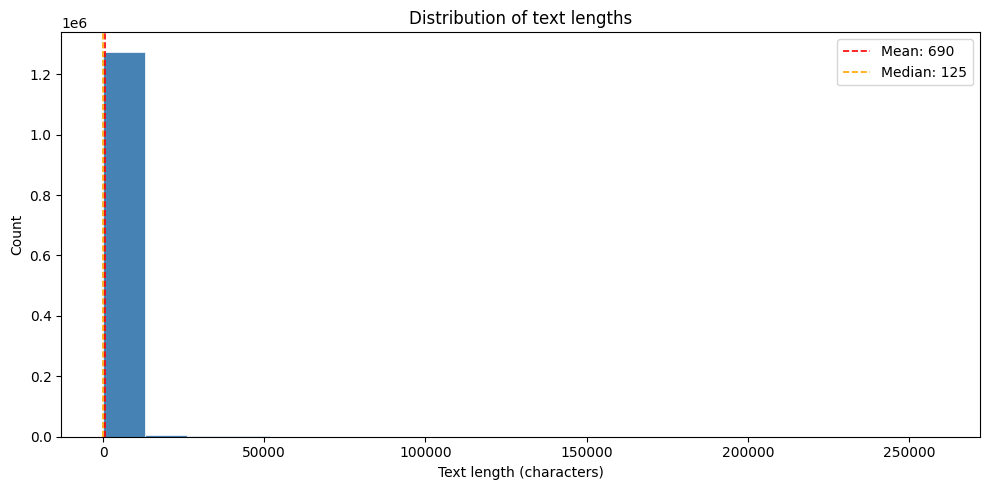

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

text_lengths = [len(text) for text in text_data]

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(text_lengths, bins=20, color='steelblue', edgecolor='white', linewidth=0.5)

ax.axvline(np.mean(text_lengths), color='red', linestyle='--', linewidth=1.2, label=f'Mean: {np.mean(text_lengths):.0f}')
ax.axvline(np.median(text_lengths), color='orange', linestyle='--', linewidth=1.2, label=f'Median: {np.median(text_lengths):.0f}')

ax.set_xlabel('Text length (characters)')
ax.set_ylabel('Count')
ax.set_title('Distribution of text lengths')
ax.legend()
plt.tight_layout()
plt.show()

In [44]:
import numpy as np
print("Average text length: ",np.mean(text_lengths))
print("Text length = 0: ", np.sum(np.array(text_lengths) == 0))
print("Quantile of 5%: ", np.quantile(text_lengths,0.05))
print("Quantile of 25%: ", np.quantile(text_lengths, 0.25))
print("Quantile of 50%: ", np.quantile(text_lengths, 0.5))
print("Quantile of 75%: ", np.quantile(text_lengths, 0.75))
print("Quantile of 95&: ", np.quantile(text_lengths, 0.95))

Average text length:  690.406322523406
Text length = 0:  0
Quantile of 5%:  58.0
Quantile of 25%:  105.0
Quantile of 50%:  125.0
Quantile of 75%:  191.0
Quantile of 95&:  2811.0


In [47]:
print(len([text_length for text_length in text_lengths if text_length > 2811]))

64240


**Data Cleaning**

**Save in jsonl**

In [ ]:
import json

with open("./data/wikipedia_vi.jsonl", "w", encoding="utf-8") as f:
    for example in dataset:
        # The dataset has a "text" column
        text = example.get("text", "").strip()
        if text:
            json.dump({"text": text}, f, ensure_ascii=False)
            f.write("\n")

print("Done writing JSONL")

In [40]:
!python "json2binidx_tool/tools/preprocess_data.py" --input "data/train_tool_data.jsonl" --output-prefix "json2binidx_tool/data/train_tool_data" --vocab "json2binidx_tool/20B_tokenizer.json" --dataset-impl mmap --tokenizer-type HFTokenizer --append-eod
!python "json2binidx_tool/tools/preprocess_data.py" --input "data/valid_tool_data.jsonl" --output-prefix "json2binidx_tool/data/valid_tool_data" --vocab "json2binidx_tool/20B_tokenizer.json" --dataset-impl mmap --tokenizer-type HFTokenizer --append-eod


0it [00:00, ?it/s]
Processed 100 documents (1037.24 docs/s, 0.31 MB/s).: : 0it [00:00, ?it/s]
Processed 200 documents (1167.14 docs/s, 0.34 MB/s).: : 100it [00:00, 604.73it/s]
Processed 200 documents (1167.14 docs/s, 0.34 MB/s).: : 200it [00:00, 1202.26it/s]
Processed 300 documents (1336.23 docs/s, 0.39 MB/s).: : 200it [00:00, 1202.26it/s]
Processed 400 documents (1380.05 docs/s, 0.40 MB/s).: : 300it [00:00, 1202.26it/s]
Processed 400 documents (1380.05 docs/s, 0.40 MB/s).: : 400it [00:00, 1453.35it/s]
Processed 500 documents (1404.48 docs/s, 0.41 MB/s).: : 400it [00:00, 1453.35it/s]
Processed 600 documents (1240.83 docs/s, 0.36 MB/s).: : 500it [00:00, 1453.35it/s]
Processed 600 documents (1240.83 docs/s, 0.36 MB/s).: : 600it [00:00, 1221.91it/s]
Processed 700 documents (1096.36 docs/s, 0.32 MB/s).: : 600it [00:00, 1221.91it/s]
Processed 800 documents (898.53 docs/s, 0.26 MB/s).: : 700it [00:00, 1221.91it/s] 
Processed 800 documents (898.53 docs/s, 0.26 MB/s).: : 800it [00:00, 771.41i


#######################################################################################################################

This tokenizer is not used in any RWKV models yet. I plan to use it for the future multilang RWKV models.

Benefits:

* Good support of most languages, from European to CJK to Arabic and Hindi and more.

* Clean vocab. Good for code too. Vocab size = 65525 (use 0 for <|endoftext|>).

* Good at numbers: the numerical tokens are '0'~'9', '10'~'99', ' 0'~' 9', ' 10'~' 99'.

* Very easy tokenization:

** The input text must be in UTF-8.

** Greedy encoding: always pick the longest (in bytes) token (with the highest id) that matches your UTF-8 bytes.

* The tokenization result is surprisingly good, because the vocab respects word boundaries and UTF-8 boundaries.

For 10x faster speed:
mypyc rwkv_tokenizer.py
python3 -c "import rwkv_tokenizer"

#######################################################################################################################

> buildi


0it [00:00, ?it/s]
Processed 100 documents (1494.66 docs/s, 0.45 MB/s).: : 0it [00:00, ?it/s]
Processed 200 documents (1956.04 docs/s, 0.57 MB/s).: : 100it [00:00, 1035.65it/s]
Processed 300 documents (2158.63 docs/s, 0.63 MB/s).: : 200it [00:00, 1500.51it/s]
Processed 300 documents (2158.63 docs/s, 0.63 MB/s).: : 300it [00:00, 2250.77it/s]
Processed 400 documents (2302.07 docs/s, 0.67 MB/s).: : 300it [00:00, 2250.77it/s]
Processed 500 documents (2197.29 docs/s, 0.64 MB/s).: : 400it [00:00, 2250.77it/s]
Processed 600 documents (1991.86 docs/s, 0.58 MB/s).: : 500it [00:00, 2250.77it/s]
Processed 600 documents (1991.86 docs/s, 0.58 MB/s).: : 600it [00:00, 1988.00it/s]
Processed 700 documents (1806.38 docs/s, 0.53 MB/s).: : 600it [00:00, 1988.00it/s]
Processed 800 documents (1778.82 docs/s, 0.52 MB/s).: : 700it [00:00, 1988.00it/s]
Processed 900 documents (1804.19 docs/s, 0.53 MB/s).: : 800it [00:00, 1988.00it/s]
Processed 900 documents (1804.19 docs/s, 0.53 MB/s).: : 900it [00:00, 1746.


#######################################################################################################################

This tokenizer is not used in any RWKV models yet. I plan to use it for the future multilang RWKV models.

Benefits:

* Good support of most languages, from European to CJK to Arabic and Hindi and more.

* Clean vocab. Good for code too. Vocab size = 65525 (use 0 for <|endoftext|>).

* Good at numbers: the numerical tokens are '0'~'9', '10'~'99', ' 0'~' 9', ' 10'~' 99'.

* Very easy tokenization:

** The input text must be in UTF-8.

** Greedy encoding: always pick the longest (in bytes) token (with the highest id) that matches your UTF-8 bytes.

* The tokenization result is surprisingly good, because the vocab respects word boundaries and UTF-8 boundaries.

For 10x faster speed:
mypyc rwkv_tokenizer.py
python3 -c "import rwkv_tokenizer"

#######################################################################################################################

> buildi

### 